In [ ]:
import os

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # force CPU, évite les problèmes GPU sous Windows

import pandas as pd
from PIL import Image
import numpy as np
import io

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model
from pyspark.sql.functions import col, pandas_udf, PandasUDFType, element_at, split
from pyspark.sql import SparkSession

import subprocess

from pyspark.ml.linalg import Vectors
import matplotlib.pyplot as plt

from pyspark.ml.feature import PCA, VectorAssembler

import findspark 
findspark.init()
findspark.find()

'C:\\Users\\jfurs\\Pythonn\\OpenClassrooms\\DS\\P9\\.venv\\lib\\site-packages\\pyspark'

In [2]:
extra_paths = r'C:\Hadoop\bin;C:\Java\jdk-11\bin'
os.environ['PATH'] = extra_paths + ';' + os.environ['PATH']
print(os.environ['PATH'])

C:\Hadoop\bin;C:\Java\jdk-11\bin;C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9\.venv/Scripts;C:\Program Files\Common Files\Oracle\Java\javapath;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1\bin\x64;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1\bin;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\NVIDIA Corporation\NVIDIA App\NvDLISR;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Program Files\Git\cmd;C:\Program Files\CMake\bin;C:\Program Files\NVIDIA Corporation\Nsight Compute 2025.4.1\;C:\Users\jfurs\.local\bin;C:\Users\jfurs\AppData\Local\Microsoft\WindowsApps;C:\Users\jfurs\AppData\Local\Programs\Microsoft VS Code\bin;C:\Users\jfurs\AppData\Local\Programs\Ollama;C:\Java\jdk-11\bin;C:\Hadoop\bin


In [3]:
print(os.environ.get("JAVA_HOME"))
print(os.environ.get("HADOOP_HOME"))

C:\Java\jdk-11
C:\Hadoop


In [4]:
ROOT = r'C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9'

PATH_Data = ROOT + r'\fruits\fruits-360_dataset\fruits-360\Test'
PATH_Result = ROOT + r'\Results'
print('PATH:        ' + \
      ROOT+'\nPATH_Data:   ' + \
      PATH_Data+'\nPATH_Result: ' + PATH_Result)

PATH:        C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9
PATH_Data:   C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9\fruits\fruits-360_dataset\fruits-360\Test
PATH_Result: C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9\Results


# PySpark (Local)

## Création d'une session Spark

In [5]:
spark = (
    SparkSession
    .builder
    .appName('P9')
    .master('local[1]')  # ← UN SEUL core, très important
    .config("spark.driver.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "8")
    .config("spark.python.worker.reuse", "true")  # réutilise le worker
    .config("spark.sql.parquet.writeLegacyFormat", 'true')
    .config("spark.authenticate", "false")
    .getOrCreate()
)

In [6]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

In [7]:
# Obtient le contexte Spark à partir de la session Spark
sc = spark.sparkContext

In [8]:
spark

In [9]:
# Affiche la configuration de Spark
print("Configuration de Spark :", spark.sparkContext.getConf().getAll())

Configuration de Spark : [('spark.driver.port', '54072'), ('spark.app.name', 'P9'), ('spark.python.worker.reuse', 'true'), ('spark.app.submitTime', '1777044048568'), ('spark.app.startTime', '1777044048766'), ('spark.executor.id', 'driver'), ('spark.sql.parquet.writeLegacyFormat', 'true'), ('spark.sql.execution.arrow.maxRecordsPerBatch', '8'), ('spark.driver.host', 'NONO'), ('spark.driver.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-U

##  Charger les fichiers binaires d'images au format .jpg à partir du chemin spécifié


In [10]:
# Filtre les fichiers avec l'extension .jpg et Recherche récursive des fichiers
images = spark.read.format("binaryFile") \
    .option("pathGlobFilter", "*.jpg") \
    .option("recursiveFileLookup", "true") \
    .load(PATH_Data)  # Charge les fichiers à partir du chemin spécifié


In [11]:
# Ajoute une colonne 'label' au DataFrame images en extrayant le répertoire parent de chaque image

images = images.withColumn('label', element_at(split(images['path'], '/'),-2))
# Affiche le schéma du DataFrame images

print(images.printSchema())
# Sélectionne les colonnes 'path' et 'label' du DataFrame images et affiche les cinq premières lignes sans tronquer les données

print(images.select('path','label').show(5,False))

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)
 |-- label: string (nullable = true)

None
+--------------------------------------------------------------------------------------------------------------------+----------+
|path                                                                                                                |label     |
+--------------------------------------------------------------------------------------------------------------------+----------+
|file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS/P9/fruits/fruits-360_dataset/fruits-360/Test/Watermelon/r_106_100.jpg|Watermelon|
|file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS/P9/fruits/fruits-360_dataset/fruits-360/Test/Watermelon/r_109_100.jpg|Watermelon|
|file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS/P9/fruits/fruits-360_dataset/fruits-360/Test/Watermelon/r_108_100.jpg|Watermelon|
|file:/C:/

### SAMPLE DE 330 PHOTOS

In [12]:
# Réduit la taille de l'échantillon images en appliquant un échantillonnage aléatoire sans remplacement avec une fraction de 0.1 (10% de l'échantillon d'origine)
# Limite le nombre de lignes de l'échantillon à 330
images=images.sample(fraction=0.1, withReplacement=False, seed=42).limit(330)

In [13]:
images.count()

330

In [14]:
images.show()

+--------------------+--------------------+------+--------------------+--------------+
|                path|    modificationTime|length|             content|         label|
+--------------------+--------------------+------+--------------------+--------------+
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7275|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7249|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7231|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7187|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7165|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7159|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:16:...|  7098|[FF D8 FF E0 00 1...|    Watermelon|
|file:/C:/Users/jf...|2026-04-24 15:15:...|  7088|[FF D8 FF E0 00 1...|Pineapple Mini|
|file:/C:/Users/jf...| 2026-04-24 15:15:41|

## MobileNetV2

- weights='imagenet': Utilise les poids pré-entraînés sur le jeu de données ImageNet. Cela signifie que le modèle sera initialisé avec des poids déjà entraînés sur le jeu de données ImageNet

- include_top=True: Inclut les couches de classification (top) dans le modèle. Les couches de classification sont les couches denses qui prennent en entrée les caractéristiques extraites par les couches convolutionnelles et produisent les prédictions de classe

- input_shape=(224, 224, 3): Spécifie la forme de l'entrée du modèle: images en couleurs (RVB) de taille 224x224 pixels.

In [15]:
#  initialisation d'un modèle (imagenet) MobileNetV2
model = MobileNetV2(weights='imagenet',
                    include_top=True,
                    input_shape=(224, 224, 3))

- new_model = Model(...): Création d'un nouveau modèle en utilisant la classe Model de Keras.

- inputs = model.input:  entrées du nouveau modèle en utilisant les mêmes entrées que le modèle model existant.

- outputs = model.layers[-2].output: Spécifie les sorties du nouveau modèle en utilisant la sortie de l'avant-dernière couche du modèle model

In [16]:
# nouveau modèle qui prend les mêmes entrées que le modèle model existant et produit les mêmes sorties que l'avant-dernière couche du modèle model

new_model = Model(inputs=model.input,
                  outputs=model.layers[-2].output)

In [17]:
# informations sur les couches, les formes de sortie et le nombre de paramètres...
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

# Diffusion des poids du modèle Tensorflow sur les workeurs

In [ ]:
# def check_parquet_tools_availability():
#     try:
#         # Exécute la commande "parquet-tools" dans le shell et capture la sortie
#         output = subprocess.check_output(["parquet-tools", "--help"])
#         print("Parquet-tools est disponible sur votre système.")
#         print(output.decode("utf-8"))  # Affiche la sortie du parquet-tools
#     except FileNotFoundError:
#         print("Parquet-tools n'est pas installé ou n'est pas accessible dans votre chemin d'exécution.")
#     except subprocess.CalledProcessError as e:
#         print(f"Erreur lors de l'exécution de parquet-tools : {e}")

# # Appel de la fonction pour vérifier la disponibilité de Parquet-tools
# check_parquet_tools_availability()

In [ ]:
# ####################### broadcast = donner les poids aux différentes machines ########################

# Diffuse les poids du nouveau modèle à travers tous les nœuds du cluster Spark  pour permettre un traitement parallèle

# broadcast_weights = sc.broadcast(new_model.get_weights())

In [ ]:
# ######################## model_fn = défninition du modèle vierge, le gèle et remove la dernière couche de classif ########################

# # crée un modèle MobileNetV2 en utilisant des poids pré-entraînés et en supprimant la couche supérieure (top layer). Les poids pré-entraînés sont obtenus à partir d'une variable broadcast_weights diffusée (broadcasted) à travers tous les nœuds du cluster Spark

# def model_fn():
#     """
#     Returns a MobileNetV2 model with top layer removed 
#     and broadcasted pretrained weights.
#     """
#     model = MobileNetV2(weights='imagenet',
#                         include_top=True,
#                         input_shape=(224, 224, 3))
#     for layer in model.layers:
#         layer.trainable = False
#     new_model = Model(inputs=model.input,
#                   outputs=model.layers[-2].output)
#     new_model.set_weights(broadcast_weights.value)
#     return new_model

- preprocess(content) :

prend du contenu brut d'image en tant qu'entrée  
Elle utilise la bibliothèque PIL (Pillow) pour ouvrir et redimensionner l'image à une taille spécifique (224x224)  
Ensuite, elle convertit l'image en un tableau NumPy  
Enfin, elle applique le prétraitement spécifique à MobileNetV2 à l'image et retourne le tableau prétraité  

- featurize_series(model, content_series) :

prend un modèle de réseau de neurones préentraîné (ici MobileNetV2) et une série Pandas contenant du contenu brut d'images  
Elle applique la fonction de prétraitement à chaque image dans la série  
Elle utilise ensuite le modèle pour prédire les features de chaque image prétraitée  
Elle aplatit les features de chaque image pour les stocker plus facilement dans des DataFrames Spark  
Elle retourne une série Pandas contenant les features aplaties de toutes les images  

- featurize_udf(content_series_iter) :

Cette fonction est un pandas UDF (User Defined Function) de type Scalar Iterator  
Elle encapsule la fonction de caractérisation pour être utilisée dans un contexte Spark  
Elle prend un itérateur en entrée, chaque élément de l'itérateur étant une série Pandas contenant des données d'images  
Elle charge le modèle une fois pour toutes les données, amortissant ainsi le coût du chargement du modèle pour chaque batch  
Pour chaque série Pandas dans l'itérateur, elle applique la fonction featurize_series et retourne les features aplaties de chaque image dans un format compatible avec Spark  

In [ ]:
# def preprocess(content):
#     """
#     Preprocesses raw image bytes for prediction.
#     """
#     img = Image.open(io.BytesIO(content)).resize([224, 224])
#     arr = img_to_array(img)
#     return preprocess_input(arr)

# ######################## featurize_series = preprocess + predict + flatten, sur un lot d'images à la fois ########################

# def featurize_series(model, content_series):
#     """
#     Featurize a pd.Series of raw images using the input model.
#     :return: a pd.Series of image features
#     """
#     input = np.stack(content_series.map(preprocess))
#     preds = model.predict(input)
#     # For some layers, output features will be multi-dimensional tensors.
#     # We flatten the feature tensors to vectors for easier storage in Spark DataFrames.
#     output = [p.flatten() for p in preds]
#     return pd.Series(output)

# ############ featurize_udf = execution par le worker de featurize_series() en réutilisant le même modèle chargé une seule fois au démarrage ############

# @pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
# def featurize_udf(content_series_iter):
#     '''
#     This method is a Scalar Iterator pandas UDF wrapping our featurization function.
#     The decorator specifies that this returns a Spark DataFrame column of type ArrayType(FloatType).

#     :param content_series_iter: This argument is an iterator over batches of data, where each batch
#                               is a pandas Series of image data.
#     '''
#     # With Scalar Iterator pandas UDFs, we can load the model once and then re-use it
#     # for multiple data batches.  This amortizes the overhead of loading big models.
#     model = model_fn()
#     for content_series in content_series_iter:
#         yield featurize_series(model, content_series)

In [ ]:
# # Configure le nombre maximal d'enregistrements par lot (batch) lors de l'exécution d'opérations SQL avec Apache Arrow

# spark.conf.set("spark.sql.execution.arrow.maxRecordsPerBatch", "1024")

In [ ]:
# # Crée un DataFrame Spark à partir du DataFrame 'images' avec 20 partitions,ce qui peut améliorer les performances lors du traitement parallèle
# # et sélectionne les colonnes 'path', 'label' et les caractéristiques (features) extraites à partir du contenu brut des images

# features_df = images.repartition(20).select(col("path"),
#                                             col("label"),
#                                             featurize_udf("content").alias("features")
#                                            )

# # Écrit le DataFrame 'features_df' au format Parquet dans le répertoire spécifié par 'PATH_Result'

# features_df.write.mode("overwrite").parquet(PATH_Result)

In [ ]:
# Contournement Windows : inférence dans le driver au lieu des workers Spark. Problème écriture avec Pyarrow

rows = images.select("path", "label", "content").collect()

results = []
for row in rows:
    img = Image.open(io.BytesIO(row['content'])).resize([224, 224])
    arr = preprocess_input(img_to_array(img))
    feat = new_model.predict(np.expand_dims(arr, 0), verbose=0).flatten()
    results.append({
        'path': row['path'],
        'label': row['label'],
        'features': feat.tolist()
    })

# Reconstruction d'un DataFrame Spark et écriture Parquet
pdf = pd.DataFrame(results)
features_df = spark.createDataFrame(pdf)
features_df.write.mode("overwrite").parquet(PATH_Result)

# PCA

In [ ]:
####### Recherche du bon K : fit une PCA à k=200, regarde la variance cumulée, détermine les k qui atteignent 80/90/95%
####### Refit d'une PCA avec k=63 (90% de variance)
####### Transform : ajoute une colonne pcaFeatures (63D) à côté de features (1280D)
####### Écriture en Parquet dans un nouveau dossier pca2
####### Relecture en pandas pour vérification finale

In [32]:
# Charge un fichier Parquet dans un DataFrame Pandas en utilisant le moteur de lecture 'pyarrow'
df = pd.read_parquet(PATH_Result, engine='pyarrow')

In [33]:
df.head()

,path,label,features
0,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.15326513350009918, 0.442253977060318, 0.0, ..."
1,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.6073659658432007, 0.06201602891087532, 0.0,..."
2,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.00234430655837059, 0.6733314990997314, 0.0,..."
3,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.03623778373003006, 0.15497517585754395, 0.0..."
4,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[1.2728379964828491, 0.5031272172927856, 0.0, ..."


In [34]:
df.loc[0,'features'].shape

(1280,)

start -----------------
  80% de variance atteint avec k = 31
  90% de variance atteint avec k = 63
  95% de variance atteint avec k = 105


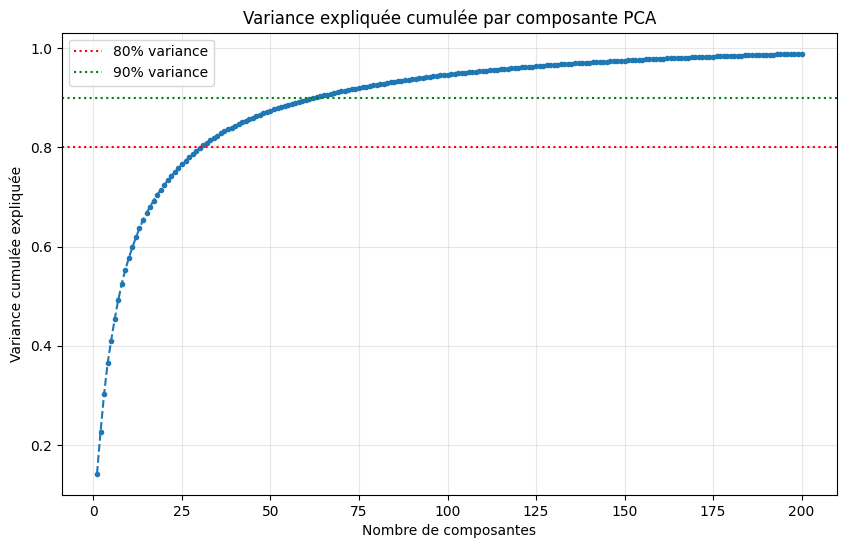

In [35]:
spark.sparkContext.setLogLevel("ERROR")

# Conversion Pandas → Spark
df['features'] = df['features'].apply(lambda x: Vectors.dense(x))
data_spark = spark.createDataFrame(df)

vecAssembler = VectorAssembler(inputCols=["features"], outputCol="features_vec")
data_spark = vecAssembler.transform(data_spark)

print('start -----------------')

# PCA avec k assez grand pour voir la vraie courbe
k_max = 200
pca = PCA(k=k_max, inputCol="features_vec", outputCol="pcaFeatures")
pcaModel = pca.fit(data_spark)
cumValues = pcaModel.explainedVariance.cumsum()

# Recherche du k optimal pour 80% et 90%
for seuil in [0.80, 0.90, 0.95]:
    mask = cumValues >= seuil
    if mask.any():
        K = np.argmax(mask) + 1
        print(f"  {int(seuil*100)}% de variance atteint avec k = {K}")
    else:
        print(f"  {int(seuil*100)}% non atteint (max = {cumValues[-1]*100:.1f}% avec k={k_max})")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, k_max + 1), cumValues, marker='o', linestyle='--', markersize=3)
plt.axhline(y=0.8, color='r', linestyle=':', label='80% variance')
plt.axhline(y=0.9, color='g', linestyle=':', label='90% variance')
plt.title('Variance expliquée cumulée par composante PCA')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée expliquée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
spark.sparkContext.setLogLevel("ERROR")

# df['features'] est déjà en DenseVector depuis la cellule précédente
df_spark = spark.createDataFrame(df)

vecAssembler = VectorAssembler(inputCols=["features"], outputCol="features_vec")
df_spark = vecAssembler.transform(df_spark)

# Utilise le k déterminé dans la cellule précédente
seuil = 0.90
mask = cumValues >= seuil
k_optimal = int(np.argmax(mask) + 1) if mask.any() else k_max
print(f"PCA avec k = {k_optimal} composantes")

pca = PCA(k=k_optimal, inputCol="features_vec", outputCol="pcaFeatures")
model = pca.fit(df_spark)

result = model.transform(df_spark)
result = result.drop('features_vec')

result.show()

PCA avec k = 63 composantes
+--------------------+--------------+--------------------+--------------------+
|                path|         label|            features|         pcaFeatures|
+--------------------+--------------+--------------------+--------------------+
|file:/C:/Users/jf...|    Watermelon|[0.15326513350009...|[-7.3002657418920...|
|file:/C:/Users/jf...|    Watermelon|[0.60736596584320...|[-4.5601906825746...|
|file:/C:/Users/jf...|    Watermelon|[0.00234430655837...|[-5.6100679535237...|
|file:/C:/Users/jf...|    Watermelon|[0.03623778373003...|[-6.4017871446122...|
|file:/C:/Users/jf...|    Watermelon|[1.27283799648284...|[-5.50173806042,3...|
|file:/C:/Users/jf...|    Watermelon|[0.95478206872940...|[-3.6838597657163...|
|file:/C:/Users/jf...|    Watermelon|[0.04353794828057...|[-6.4280793722408...|
|file:/C:/Users/jf...|Pineapple Mini|[0.0,4.7492756843...|[8.08432454675746...|
|file:/C:/Users/jf...|Pineapple Mini|[0.0,4.7234706878...|[8.23262765712606...|
|file:/C:/Us

In [37]:
result.write.mode('overwrite').parquet(r'C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9\pca2')

In [38]:
df = spark.read.parquet(r'C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P9\pca2').toPandas()

In [39]:
df

,path,label,features,pcaFeatures
0,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.15326513350009918, 0.442253977060318, 0.0, ...","[-7.300265741892097, 3.946652047715865, 2.4270..."
1,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.6073659658432007, 0.06201602891087532, 0.0,...","[-4.560190682574604, 3.900594255195492, 2.0613..."
2,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.00234430655837059, 0.6733314990997314, 0.0,...","[-5.610067953523787, 3.568504418488158, -2.787..."
3,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[0.03623778373003006, 0.15497517585754395, 0.0...","[-6.401787144612262, 4.374495793344662, 3.2534..."
4,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Watermelon,"[1.2728379964828491, 0.5031272172927856, 0.0, ...","[-5.50173806042, 3.820811236319819, 1.19928094..."
...,...,...,...,...
325,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Apple Red 3,"[1.2792786359786987, 0.22159962356090546, 0.0,...","[-8.981149528643682, -3.530413186030104, -6.49..."
326,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Nectarine Flat,"[0.3244713842868805, 0.04023914784193039, 0.0,...","[-12.010202772918438, -6.708387588490504, 0.90..."
327,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Pear Stone,"[0.0, 0.0, 0.4110502004623413, 0.0, 0.0, 0.0, ...","[-7.271549451979271, 6.05151693109124, -5.9140..."
328,file:/C:/Users/jfurs/Pythonn/OpenClassrooms/DS...,Pear Stone,"[0.0, 0.09422197937965393, 0.06528645753860474...","[-9.221175207068505, 3.2931777788814824, -5.24..."
